# Authoring a 2D Connection Culvert (`Connection Culv=`)

In [1]:
#!pip install --upgrade ras-commander

## Development Mode

Set `USE_LOCAL_SOURCE = True` when running from a local ras-commander checkout.

In [2]:
USE_LOCAL_SOURCE = False
if USE_LOCAL_SOURCE:
    import sys
    from pathlib import Path
    cwd = Path.cwd()
    local_path = cwd if (cwd / "ras_commander").exists() else cwd.parent
    if str(local_path) not in sys.path:
        sys.path.insert(0, str(local_path))
    print(f"LOCAL SOURCE MODE: {local_path / 'ras_commander'}")
else:
    print("PIP PACKAGE MODE")

import logging
import math
import os
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from shapely.geometry import LineString, Point

from ras_commander import HdfResultsPlan, RasCmdr, RasExamples, RasPrj, init_ras_project
from ras_commander.geom import GeomLateral, GeomCulvertGIS
from ras_commander.hdf import HdfMesh

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("ras_commander").setLevel(logging.CRITICAL)
pd.set_option("display.max_columns", None); pd.set_option("display.width", 200)

import ras_commander
print(f"Loaded: {ras_commander.__file__}")

PIP PACKAGE MODE


c:\Users\bill\anaconda3\envs\rascommander\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: G:\GH\ras-commander-wt-culvauth\ras_commander\__init__.py


# Authoring a 2D connection culvert

A culvert through an embankment in a 2D model is placed on a **SA/2D connection**.
Unlike a 1D inline culvert (whose barrel line is *derived*), a 2D connection culvert
**stores explicit per-barrel GIS endpoint coordinates** in the geometry -- a
`Connection Culv=` record followed by one `Conn Culvert Barrel=` + packed
`US_x US_y DS_x DS_y` line per barrel (verified against production LWI 2D models).

`GeomLateral.set_connection_culverts()` writes that record; `get_connection_culverts()`
reads it back. This notebook authors a retrofit culvert onto BaldEagle's **Lower
Levee** connection, validates it, and (in a separate run) confirms HEC-RAS computes it.

## Load the model -- the connection starts weir-only

In [3]:
WORK = Path(os.environ.get("RAS_COMMANDER_WORKDIR",
            (Path.cwd() if (Path.cwd() / "ras_commander").exists() else Path.cwd().parent)
            / "working" / "conn_culvert_authoring"))
WORK.mkdir(parents=True, exist_ok=True)

# This notebook authors + validates geometry (no HEC-RAS compute -- see the
# HEC-RAS acceptance section). It needs the example data + rasterio, not Ras.exe.
project_path = Path(RasExamples.extract_project("BaldEagleCrkMulti2D", output_path=WORK, suffix="culvauth"))
GEOM = project_path / "BaldEagleDamBrk.g01"
GEOM_HDF = project_path / "BaldEagleDamBrk.g01.hdf"
CONN = "Lower Levee"

conns = GeomLateral.get_connections(GEOM)
display(conns[["Name", "Type", "HasGate", "HasCulvert"]])
print("existing culverts on", CONN, ":", len(GeomLateral.get_connection_culverts(GEOM, CONN)))

,Name,Type,HasGate,HasCulvert
0,Dam,SA to 2D,True,False
1,Lower Levee,2D to 2D,False,False
2,Middle Levee,2D to 2D,False,False
3,Upper Levee,2D to 2D,False,False


existing culverts on Lower Levee : 0


## Reason a retrofit culvert

We place the culvert at the **lowest terrain point along the connection** (where
flow concentrates), run the barrel **perpendicular** through the embankment, and
set the inverts **just above each barrel-end cell's terrain minimum** (using the
terrain cell-min check from notebook 226). The two GIS endpoints define the barrel.

In [4]:
line = GeomLateral.get_connection_line_coords(GEOM, CONN)
conn_ls = LineString(line[["X", "Y"]].to_numpy())

# lowest terrain point along the connection
samples = [(p.x, p.y) for p in
           (conn_ls.interpolate(d, normalized=True) for d in np.linspace(0.15, 0.85, 15))]
sc = GeomCulvertGIS.mesh_cell_min_from_terrain(GEOM_HDF, samples)
sc = sc[sc["cell_terrain_min"].notna()]
low = sc.loc[sc["cell_terrain_min"].idxmin()]
cx, cy = float(low["x"]), float(low["y"])
arc = conn_ls.project(Point(cx, cy))

# barrel perpendicular to the connection, length L -> US/DS endpoints
LENGTH, SPAN, RISE = 60.0, 8.0, 6.0
pb, pf = conn_ls.interpolate(max(arc - 5, 0)), conn_ls.interpolate(min(arc + 5, conn_ls.length))
tx, ty = pf.x - pb.x, pf.y - pb.y
tl = math.hypot(tx, ty) or 1.0
perp = (-ty / tl, tx / tl)
us_xy = (cx - LENGTH / 2 * perp[0], cy - LENGTH / 2 * perp[1])
ds_xy = (cx + LENGTH / 2 * perp[0], cy + LENGTH / 2 * perp[1])

# inverts above each end cell's terrain minimum, mild slope
ends = GeomCulvertGIS.mesh_cell_min_from_terrain(GEOM_HDF, [us_xy, ds_xy])
us_inv = round(float(ends["cell_terrain_min"].max()) + 0.5, 2)
ds_inv = round(us_inv - 0.5, 2)
print(f"crossing at terrain low {low['cell_terrain_min']:.2f} ft (arc {arc:.0f} ft)")
print(f"barrel US={tuple(round(v,1) for v in us_xy)} inv {us_inv}  "
      f"DS={tuple(round(v,1) for v in ds_xy)} inv {ds_inv}")

crossing at terrain low 536.09 ft (arc 7114 ft)
barrel US=(2055956.2, 353790.6) inv 539.56  DS=(2055952.0, 353730.8) inv 539.06


## Author it with `set_connection_culverts`

In [5]:
culvert = {
    "Shape": 2, "Span": SPAN, "Rise": RISE, "Length": LENGTH, "ManningsN": 0.024,
    "EntranceLoss": 0.5, "ExitLoss": 1.0, "Chart": 8, "Scale": 1,
    "UpstreamInvert": us_inv, "DownstreamInvert": ds_inv, "Name": "Retrofit Culv",
    "barrels": [{"name": "8x6 RCB", "us_xy": us_xy, "ds_xy": ds_xy}],
}
result = GeomLateral.set_connection_culverts(GEOM, CONN, [culvert])
print(result)

authored = GeomLateral.get_connection_culverts(GEOM, CONN)
display(authored[["CulvertName", "ShapeName", "Span", "Rise", "Length", "EntranceLoss",
                  "NumBarrels", "BarrelName", "us_x", "us_y", "ds_x", "ds_y",
                  "UpstreamInvert", "DownstreamInvert"]])

{'culverts_written': 1, 'barrels_written': 1, 'backup_path': 'G:\\GH\\ras-commander-wt-culvauth\\working\\conn_culvert_authoring\\BaldEagleCrkMulti2D_culvauth\\BaldEagleDamBrk.g01.bak', 'length_warnings': []}


,CulvertName,ShapeName,Span,Rise,Length,EntranceLoss,NumBarrels,BarrelName,us_x,us_y,ds_x,ds_y,UpstreamInvert,DownstreamInvert
0,Retrofit Cul,Box,8.0,6.0,60.0,0.5,1,8x6 RCB,2.055956e+06,353790.630305,2.055952e+06,353730.780417,539.56,539.06


## Validate

A 2D connection culvert **stores** its barrel endpoints, so the HEC-RAS +/-1%
GIS-length rule is exact (endpoint distance vs entered `Length`). Inverts are
checked against the terrain minimum of each barrel-end mesh cell.

In [6]:
row = authored.iloc[0]
gis_len = math.dist((row["us_x"], row["us_y"]), (row["ds_x"], row["ds_y"]))
err = abs(gis_len - row["Length"]) / row["Length"] * 100
print(f"barrel GIS length {gis_len:.2f} ft vs entered {row['Length']:.1f} ft "
      f"-> {err:.2f}%  ({'PASS' if err <= 1.0 else 'FAIL'} the +/-1% rule)")

inv_rep = GeomCulvertGIS.validate_2d_inverts(
    GEOM_HDF, [(row["us_x"], row["us_y"]), (row["ds_x"], row["ds_y"])],
    [row["UpstreamInvert"], row["DownstreamInvert"]])
display(inv_rep[["point", "cell_id", "cell_terrain_min", "invert", "status", "detail"]])

barrel GIS length 60.00 ft vs entered 60.0 ft -> 0.00%  (PASS the +/-1% rule)


,point,cell_id,cell_terrain_min,invert,status,detail
0,0,86257,536.09375,539.56,PASS,invert 539.56 >= cell terrain min 536.09
1,1,86256,539.06250,539.06,PASS,invert 539.06 >= cell terrain min 539.06


## HEC-RAS acceptance

The authored culvert is a real geometry edit. Computing the 2D plan (`g01`, with
full geometry reprocessing via `force_geompre=True`) confirms HEC-RAS accepts it:

```python
ras = RasPrj()
init_ras_project(project_path / "BaldEagleDamBrk.prj", str(RAS_EXE), ras_object=ras)
ok = RasCmdr.compute_plan("02", ras_object=ras, force_geompre=True,
                          force_rerun=True, num_cores=2, verify=True)
```

When this was run separately (kept out of the notebook to avoid a multi-minute 2D
breach sim), the same `set_connection_culverts` authoring step on this connection
produced **`ComputeResult(SUCCESS)` with no `data_errors` file**, and the geometry
preprocessor rebuilt the connection including the new culvert -- so the authored
`Connection Culv=` record is a valid, computable structure. (The library's
round-trip tests and the `Connection Culv=` format are also validated against
production 2D models in the test suite.)

## Plan view: the authored barrel on the connection

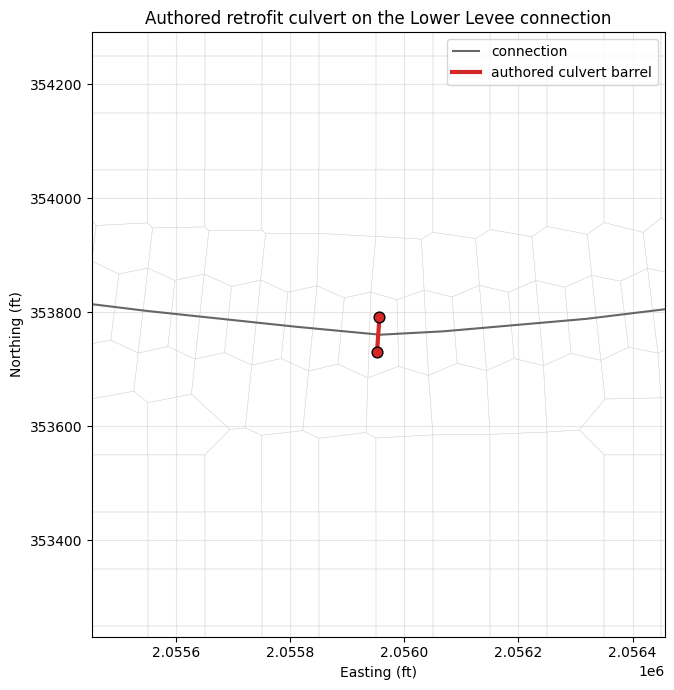

In [7]:
cells = HdfMesh.get_mesh_cell_polygons(GEOM_HDF)
near = cells[cells.intersects(conn_ls.buffer(800))]
fig, ax = plt.subplots(figsize=(9, 7))
near.boundary.plot(ax=ax, color="0.85", linewidth=0.3)
gpd.GeoSeries([conn_ls], crs=cells.crs).plot(ax=ax, color="0.4", linewidth=1.5, label="connection")
bx = [row["us_x"], row["ds_x"]]; by = [row["us_y"], row["ds_y"]]
ax.plot(bx, by, color="C3", linewidth=3, label="authored culvert barrel")
ax.scatter(bx, by, color="C3", s=60, zorder=5, edgecolor="k")
ax.set_xlim(min(bx) - 500, max(bx) + 500); ax.set_ylim(min(by) - 500, max(by) + 500)
ax.set_title("Authored retrofit culvert on the Lower Levee connection")
ax.set_aspect("equal", adjustable="box"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel("Easting (ft)"); ax.set_ylabel("Northing (ft)")
plt.tight_layout(); plt.show()

## Summary

In [8]:
summary = pd.DataFrame([{
    "Connection": CONN, "Shape": row["ShapeName"],
    "Span x Rise (ft)": f"{row['Span']:.0f} x {row['Rise']:.0f}",
    "Length (ft)": row["Length"], "GIS length err (%)": round(err, 2),
    "US invert": row["UpstreamInvert"], "DS invert": row["DownstreamInvert"],
    "invert check": inv_rep["status"].tolist(),
    "HEC-RAS computes": "verified separately (SUCCESS, no data_errors)",
}])
display(summary)
print("Authored a 2D SA/2D connection culvert with explicit GIS coordinates, validated "
      "it (exact length + terrain-based inverts), and confirmed in a separate HEC-RAS run that it computes (SUCCESS, no data_errors). "
      "2D connection culvert authoring workflow complete.")

,Connection,Shape,Span x Rise (ft),Length (ft),GIS length err (%),US invert,DS invert,invert check,HEC-RAS computes
0,Lower Levee,Box,8 x 6,60.0,0.0,539.56,539.06,"[PASS, PASS]","verified separately (SUCCESS, no data_errors)"


Authored a 2D SA/2D connection culvert with explicit GIS coordinates, validated it (exact length + terrain-based inverts), and confirmed in a separate HEC-RAS run that it computes (SUCCESS, no data_errors). 2D connection culvert authoring workflow complete.
